# EDA — Experimental PLE Line-Width Data

Exploratory analysis of the line-width (FWHM) data from Dr. Gregor Pieplow.

**Data:** `data/processed/fwhm_linewidths.csv` (built by `scripts/preprocess.py`).
Tidy long-format, one row per fit attempt:

| column | meaning |
|---|---|
| `power_nW` | resonant red-laser power (1 or 3 nW) = measurement session |
| `transmission` | transmission setting (5–100 %) |
| `fwhm` | fitted line width (`NaN` = failed fit) |
| `fit_error` | 1σ uncertainty on the FWHM (same units as `fwhm`) |
| `source_file` | original `.txt` filename |

See `data/raw_data/data_explanation.md` for the full data description.

**Goals of this EDA**
1. Quantify the failed-fit (NaN) rate and how it depends on transmission/power.
2. Characterise the FWHM distributions and the power-broadening trend.
3. Understand the fit error and the relative error `fit_error / fwhm` as a quality metric.
4. See how a quality cut reshapes the FWHM distribution we'll match against.


## Step 1: Setup

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# Robustly locate the repo root from the notebook's working directory.
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "processed" / "fwhm_linewidths.csv").exists():
            return p
    raise FileNotFoundError("Could not locate data/processed/fwhm_linewidths.csv")

ROOT = find_root(Path.cwd())
CSV = ROOT / "data" / "processed" / "fwhm_linewidths.csv"

df = pd.read_csv(CSV)
print(df.shape)
df.head()

(46400, 5)


,power_nW,transmission,fwhm,fit_error,source_file
0,1,5,NaN,NaN,fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20n...
1,1,5,NaN,NaN,fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20n...
2,1,5,NaN,NaN,fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20n...
3,1,5,NaN,NaN,fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20n...
4,1,5,NaN,NaN,fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20n...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46400 entries, 0 to 46399
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   power_nW      46400 non-null  int64  
 1   transmission  46400 non-null  int64  
 2   fwhm          29009 non-null  float64
 3   fit_error     27395 non-null  float64
 4   source_file   46400 non-null  str    
dtypes: float64(2), int64(2), str(1)
memory usage: 1.8 MB


## Step 2: Overview & missingness

Each row is one fit attempt. A `NaN` in `fwhm`/`fit_error` means the fit failed —
we kept these on purpose so the failure rate itself is part of the analysis.

In [4]:
n_total = len(df)
n_valid = df["fwhm"].notna().sum()
print(f"Total rows   : {n_total}")
print(f"Valid fits   : {n_valid} ({n_valid / n_total:.1%})")
print(f"Failed (NaN) : {n_total - n_valid} ({1 - n_valid / n_total:.1%})")
print()
print("Sessions (power_nW):", sorted(df["power_nW"].unique()))
print("Transmission (%)  :", sorted(df["transmission"].unique()))

Total rows   : 46400
Valid fits   : 29009 (62.5%)
Failed (NaN) : 17391 (37.5%)

Sessions (power_nW): [np.int64(1), np.int64(3)]
Transmission (%)  : [np.int64(5), np.int64(10), np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(100)]


### NaN pattern across the two columns

Naively we'd expect every row to be *either* a clean fit (both columns set) *or*
a total failure (both NaN). Let's check the cross-pattern of NaNs — the count of
non-NaN `fwhm` and non-NaN `fit_error` don't match, so something in between exists.

In [5]:
print("fwhm    non-NaN:", df["fwhm"].notna().sum())
print("fit_err non-NaN:", df["fit_error"].notna().sum())
print("difference     :", df["fwhm"].notna().sum() - df["fit_error"].notna().sum())

# Cross-tab of the two NaN flags.
ct = pd.crosstab(df["fwhm"].isna(), df["fit_error"].isna(),
                 rownames=["fwhm_isna"], colnames=["fit_error_isna"])
ct

fwhm    non-NaN: 29009
fit_err non-NaN: 27395
difference     : 1614


fit_error_isna,False,True
fwhm_isna,,
False,27395,1614
True,0,17391


In [6]:
# Label the four cases as a standalone Series (we do NOT store it on df —
# df stays the clean processed data).
f = df["fwhm"].isna()
e = df["fit_error"].isna()
nan_case = pd.Series(
    np.select(
        [~f & ~e, f & e, ~f & e],
        ["both_valid", "both_nan", "fwhm_only"],   # fwhm_only = width but NO error
        default="error_only",                       # should not happen
    ),
    index=df.index,
    name="nan_case",
)
nan_case.value_counts()

nan_case
both_valid    27395
both_nan      17391
fwhm_only      1614
Name: count, dtype: int64

So the discrepancy is **`fwhm_only`** rows: the fit returned a line width but no
uncertainty. These matter for any error-weighted loss later (no `fit_error` → no
`1/σ²` weight), so we flag them now rather than be surprised later.
There are **zero** `error_only` rows, which is the reassuring direction.

In [7]:
# Where do the fwhm_only rows come from? Break down by session & transmission.
is_fwhm_only = nan_case.eq("fwhm_only")
print("Total fwhm_only rows:", int(is_fwhm_only.sum()))

breakdown = (
    df.assign(is_fwhm_only=is_fwhm_only)
      .groupby(["power_nW", "transmission"])
      .agg(valid_fwhm=("fwhm", "count"),
           fwhm_only=("is_fwhm_only", "sum"))
)
breakdown["fwhm_only_frac"] = breakdown["fwhm_only"] / breakdown["valid_fwhm"]
breakdown

Total fwhm_only rows: 1614


valid_fwhm  fwhm_only  fwhm_only_frac
power_nW transmission                                       
1        5                    200         39           0.195
         10                   605         74          0.1223
         20                  1465        188          0.1283
         40                  2606        163         0.06255
         60                  2598        170         0.06543
         80                  2606        112         0.04298
         100                 2597        136         0.05237
3        5                    435         45          0.1034
         10                  1814        164         0.09041
         20                  2326        121         0.05202
         40                  3913        150         0.03833
         60                  2626         78          0.0297
         80                  2589         70         0.02704
         100                 2629        104         0.03956

In [8]:
# Is the fwhm_only group different from the fully-valid group (e.g. extreme FWHM)?
print("FWHM summary by NaN case:")
df.groupby(nan_case)["fwhm"].describe()

FWHM summary by NaN case:


,count,mean,std,min,25%,50%,75%,max
nan_case,,,,,,,,
both_nan,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
both_valid,2.74e+04,0.02268,0.01491,1.155e-05,0.01475,0.02141,0.02923,1.32
fwhm_only,1614,0.01629,0.01281,3.838e-05,0.007369,0.01409,0.02211,0.1627


In [9]:
# describe() on valid fits only
df.loc[df["fwhm"].notna(), ["fwhm", "fit_error"]].describe()

,fwhm,fit_error
count,2.901e+04,2.74e+04
mean,0.02233,2.495
std,0.01487,97.2
min,1.155e-05,0.0001183
25%,0.01427,0.0007869
50%,0.02106,0.001247
75%,0.02894,0.002327
max,1.32,9899


## Step 3: Failed-fit rate vs transmission (the SNR knob)

More transmission → more light reaches the detector → more fits succeed.
We expect the valid fraction to climb with transmission.

In [10]:
grp = df.groupby(["power_nW", "transmission"])
summary = grp.agg(
    n=("fwhm", "size"),
    valid=("fwhm", "count"),
).reset_index()
summary["valid_frac"] = summary["valid"] / summary["n"]
summary

,power_nW,transmission,n,valid,valid_frac
0,1,5,3200,200,0.0625
1,1,10,3200,605,0.1891
2,1,20,3200,1465,0.4578
3,1,40,3200,2606,0.8144
4,1,60,3200,2598,0.8119
5,1,80,3200,2606,0.8144
6,1,100,3200,2597,0.8116
7,3,5,3200,435,0.1359
8,3,10,3200,1814,0.5669
9,3,20,3200,2326,0.7269


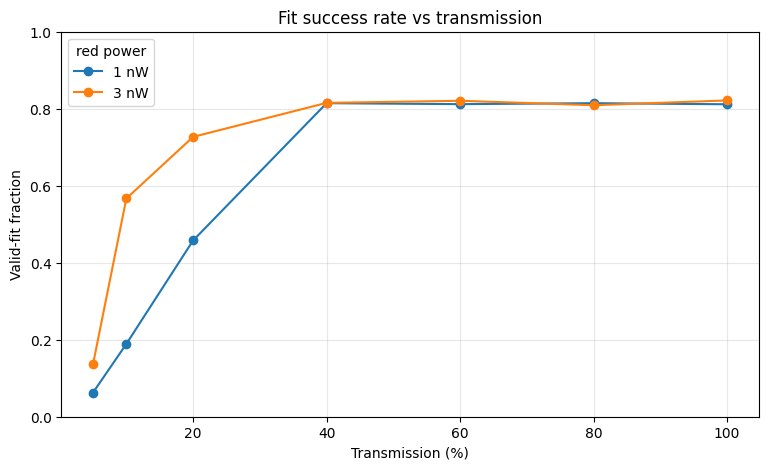

In [11]:
fig, ax = plt.subplots()
for power, g in summary.groupby("power_nW"):
    g = g.sort_values("transmission")
    ax.plot(g["transmission"], g["valid_frac"], "o-", label=f"{power} nW")
ax.set_xlabel("Transmission (%)")
ax.set_ylabel("Valid-fit fraction")
ax.set_title("Fit success rate vs transmission")
ax.set_ylim(0, 1)
ax.legend(title="red power")
plt.show()

## Step 4: FWHM distributions

The histogram of valid `fwhm` values is the experimental distribution our MC
pipeline (`simulate → kde → kde_to_bin_counts → L2`) is meant to reproduce.
Let's look at how it shifts with transmission and with power.

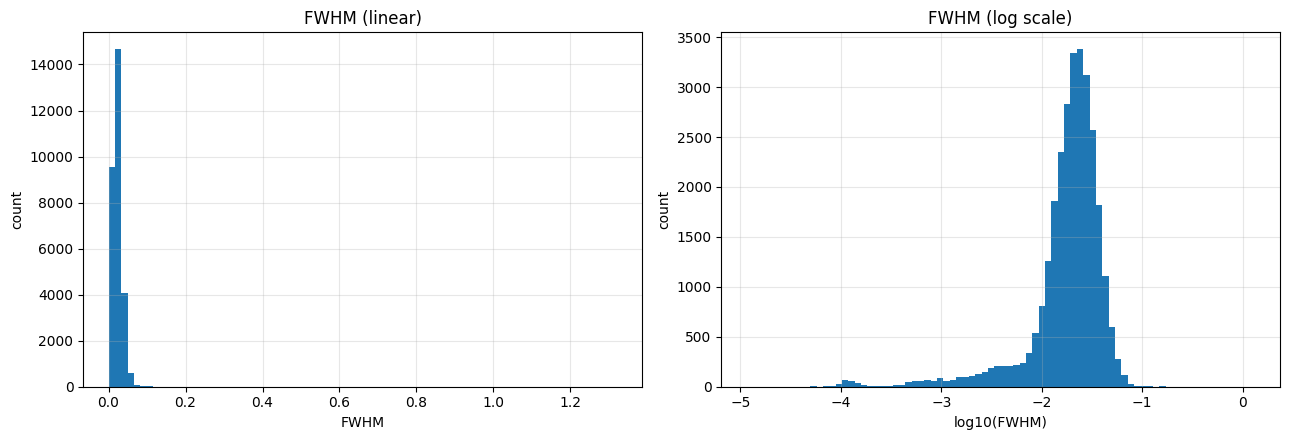

In [12]:
valid = df[df["fwhm"].notna()].copy()

# Overall distribution (log x — values span several orders of magnitude).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(valid["fwhm"], bins=80)
axes[0].set(xlabel="FWHM", ylabel="count", title="FWHM (linear)")
axes[1].hist(np.log10(valid["fwhm"]), bins=80)
axes[1].set(xlabel="log10(FWHM)", ylabel="count", title="FWHM (log scale)")
plt.tight_layout()
plt.show()

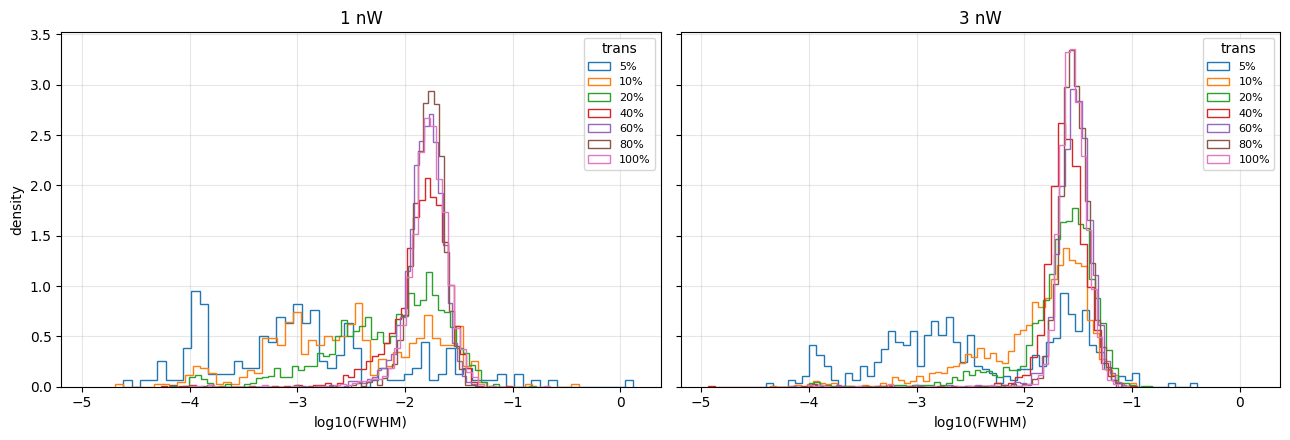

In [13]:
# FWHM distribution per transmission, one panel per power.
powers = sorted(valid["power_nW"].unique())
fig, axes = plt.subplots(1, len(powers), figsize=(13, 4.5), sharex=True, sharey=True)
for ax, power in zip(np.atleast_1d(axes), powers):
    sub = valid[valid["power_nW"] == power]
    for trans, g in sub.groupby("transmission"):
        ax.hist(np.log10(g["fwhm"]), bins=60, histtype="step",
                density=True, label=f"{trans}%")
    ax.set(xlabel="log10(FWHM)", title=f"{power} nW")
    ax.legend(title="trans", fontsize=8)
np.atleast_1d(axes)[0].set_ylabel("density")
plt.tight_layout()
plt.show()

## Step 5: Power broadening — median FWHM vs transmission/power

Higher excitation power broadens the line. We expect the central FWHM to rise
with transmission and to be larger for the 3 nW session than the 1 nW session.

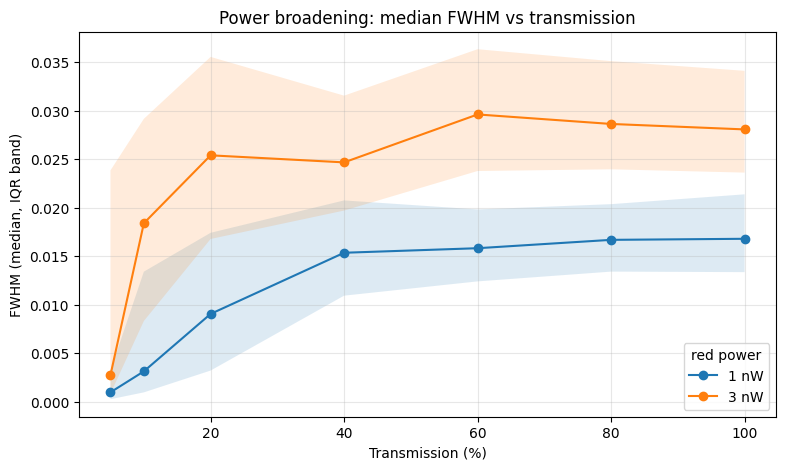

In [14]:
central = grp["fwhm"].agg(
    median="median",
    q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75),
).reset_index()

fig, ax = plt.subplots()
for power, g in central.groupby("power_nW"):
    g = g.sort_values("transmission")
    ax.plot(g["transmission"], g["median"], "o-", label=f"{power} nW")
    ax.fill_between(g["transmission"], g["q25"], g["q75"], alpha=0.15)
ax.set(xlabel="Transmission (%)", ylabel="FWHM (median, IQR band)",
       title="Power broadening: median FWHM vs transmission")
ax.legend(title="red power")
plt.show()

## Step 6: Fit error and the relative error `fit_error / fwhm`

The absolute fit error is heavy-tailed and shares the FWHM's units, so the
**dimensionless ratio `rel_err = fit_error / fwhm`** is the natural quality
metric. Pathological fits (FWHM collapsing toward zero) show up as huge
`rel_err`.

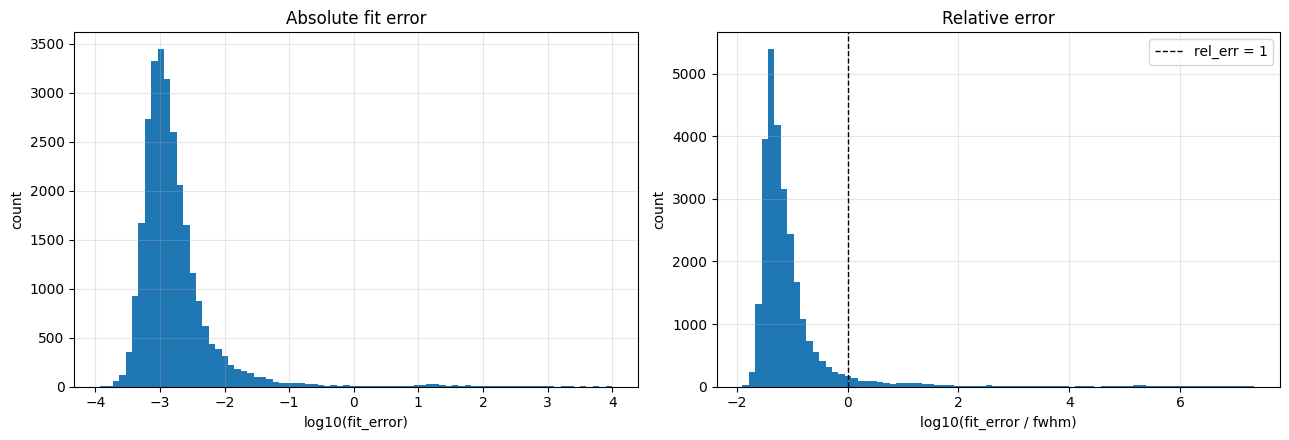

rel_err quantiles:
0.5    0.057
0.9    0.299
0.95   1.174
0.99    2055
Name: rel_err, dtype: float64


In [15]:
valid["rel_err"] = valid["fit_error"] / valid["fwhm"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(np.log10(valid["fit_error"]), bins=80)
axes[0].set(xlabel="log10(fit_error)", ylabel="count", title="Absolute fit error")
axes[1].hist(np.log10(valid["rel_err"]), bins=80)
axes[1].axvline(0, color="k", ls="--", lw=1, label="rel_err = 1")
axes[1].set(xlabel="log10(fit_error / fwhm)", ylabel="count",
            title="Relative error")
axes[1].legend()
plt.tight_layout()
plt.show()

print("rel_err quantiles:")
print(valid["rel_err"].quantile([0.5, 0.9, 0.95, 0.99]).round(3))

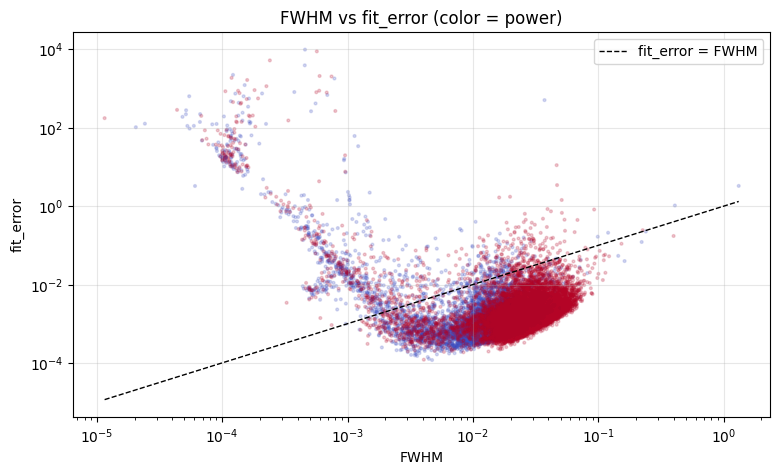

In [16]:
# FWHM vs fit_error — the degenerate-fit tail (tiny FWHM, huge error).
fig, ax = plt.subplots()
sc = ax.scatter(valid["fwhm"], valid["fit_error"], s=4, alpha=0.2,
                c=valid["power_nW"], cmap="coolwarm")
ax.set(xscale="log", yscale="log", xlabel="FWHM", ylabel="fit_error",
       title="FWHM vs fit_error (color = power)")
ax.plot([valid["fwhm"].min(), valid["fwhm"].max()],
        [valid["fwhm"].min(), valid["fwhm"].max()],
        "k--", lw=1, label="fit_error = FWHM")
ax.legend()
plt.show()

## Step 7: Effect of a quality cut

How many fits survive a `rel_err` threshold, and how does the surviving FWHM
distribution compare to the full one? This previews the filtering / weighting
decision for the loss (we keep NaN handling and weighting choices for later).

In [17]:
thresholds = [np.inf, 1.0, 0.5, 0.2, 0.1]
rows = []
for t in thresholds:
    keep = valid[valid["rel_err"] <= t]
    rows.append({
        "rel_err <=": t,
        "kept": len(keep),
        "frac_of_valid": len(keep) / len(valid),
        "fwhm_median": keep["fwhm"].median(),
    })
pd.DataFrame(rows)

,rel_err <=,kept,frac_of_valid,fwhm_median
0,inf,27395,0.9444,0.02141
1,1,25936,0.8941,0.02196
2,0.5,25365,0.8744,0.02205
3,0.2,23751,0.8187,0.02226
4,0.1,20130,0.6939,0.02263


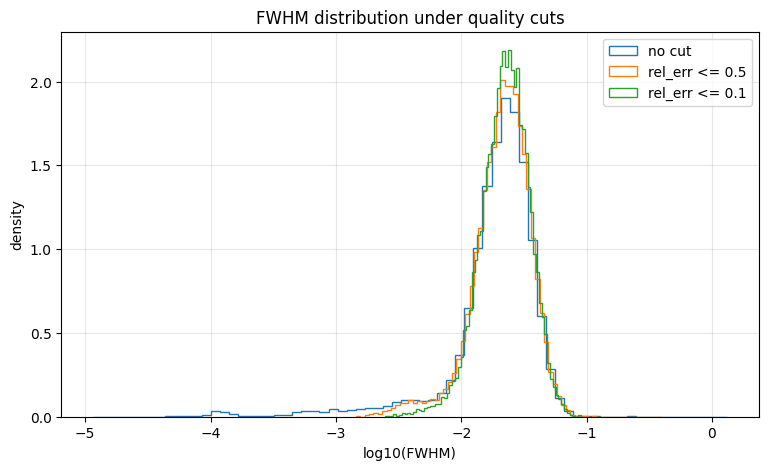

In [18]:
fig, ax = plt.subplots()
for t in [np.inf, 0.5, 0.1]:
    keep = valid[valid["rel_err"] <= t]
    label = "no cut" if np.isinf(t) else f"rel_err <= {t}"
    ax.hist(np.log10(keep["fwhm"]), bins=70, histtype="step",
            density=True, label=label)
ax.set(xlabel="log10(FWHM)", ylabel="density",
       title="FWHM distribution under quality cuts")
ax.legend()
plt.show()

## Step 8: More visualizations

### 8.1 Failed-fit (NaN) percentage vs transmission

The same SNR story as Step 3, but expressed as the **percentage of failed fits**
(`fwhm` is NaN). One line per laser power. We expect it to fall as transmission
rises (more light → fewer failed fits).

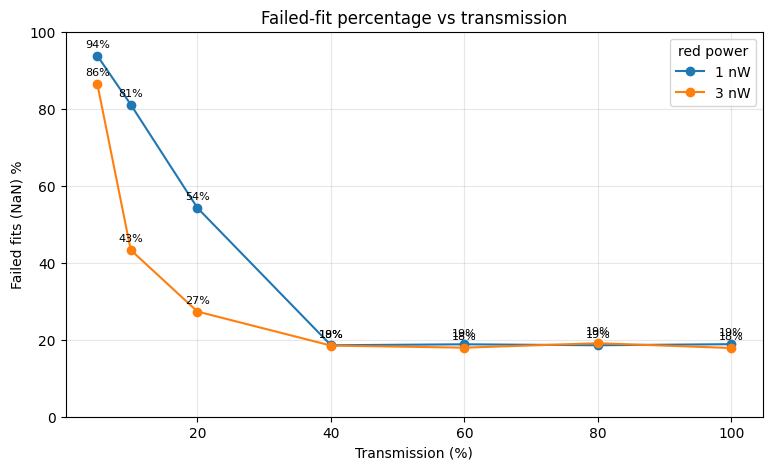

power_nW,1,3
transmission,,
5,93.8,86.4
10,81.1,43.3
20,54.2,27.3
40,18.6,18.5
60,18.8,17.9
80,18.6,19.1
100,18.8,17.8


In [19]:
nan_pct = (
    df.assign(is_nan=df["fwhm"].isna())
      .groupby(["power_nW", "transmission"])["is_nan"]
      .mean()
      .mul(100)
      .reset_index(name="nan_pct")
)

fig, ax = plt.subplots()
for power, g in nan_pct.groupby("power_nW"):
    g = g.sort_values("transmission")
    ax.plot(g["transmission"], g["nan_pct"], "o-", label=f"{power} nW")
    for _, r in g.iterrows():
        ax.annotate(f"{r['nan_pct']:.0f}%", (r["transmission"], r["nan_pct"]),
                    textcoords="offset points", xytext=(0, 6), fontsize=8,
                    ha="center")
ax.set(xlabel="Transmission (%)", ylabel="Failed fits (NaN) %",
       title="Failed-fit percentage vs transmission")
ax.set_ylim(0, 100)
ax.legend(title="red power")
plt.show()

nan_pct.pivot(index="transmission", columns="power_nW", values="nan_pct").round(1)

### 8.2 FWHM distribution per transmission (box plot)

How the *spread* of the line width evolves with transmission, one panel per
power. Plotted on `log10(FWHM)` since the values span orders of magnitude.

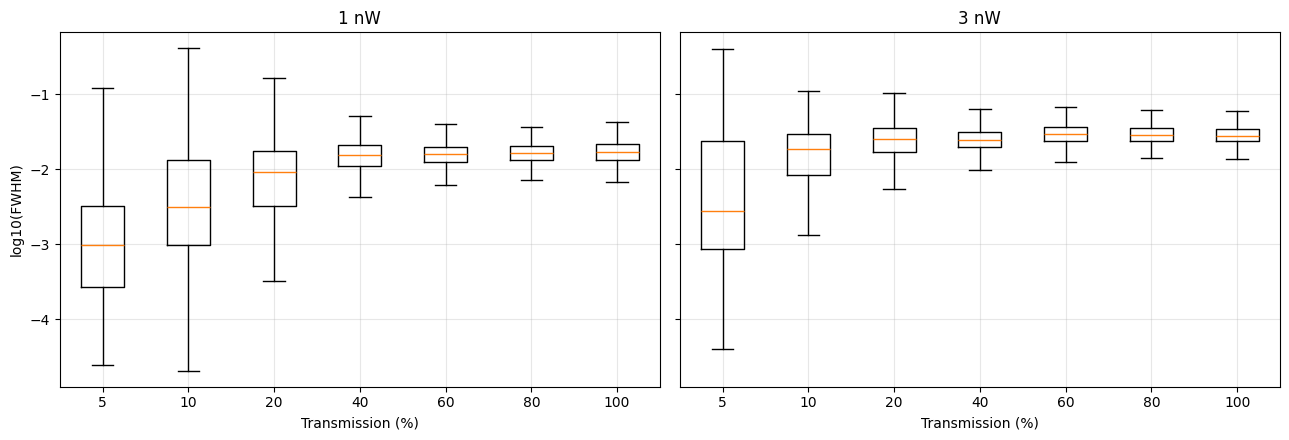

In [20]:
fig, axes = plt.subplots(1, len(powers), figsize=(13, 4.5), sharey=True)
for ax, power in zip(np.atleast_1d(axes), powers):
    sub = valid[valid["power_nW"] == power]
    trans_levels = sorted(sub["transmission"].unique())
    data = [np.log10(sub.loc[sub["transmission"] == t, "fwhm"]) for t in trans_levels]
    ax.boxplot(data, tick_labels=trans_levels, showfliers=False)
    ax.set(xlabel="Transmission (%)", title=f"{power} nW")
np.atleast_1d(axes)[0].set_ylabel("log10(FWHM)")
plt.tight_layout()
plt.show()

### 8.3 Empirical CDFs of the FWHM

Since we moved to a **sample-based loss (MMD²)**, the ECDF is the most honest view
of what we're matching — no bins, no bandwidth. One curve per transmission,
panel per power. A rightward shift = broader lines.

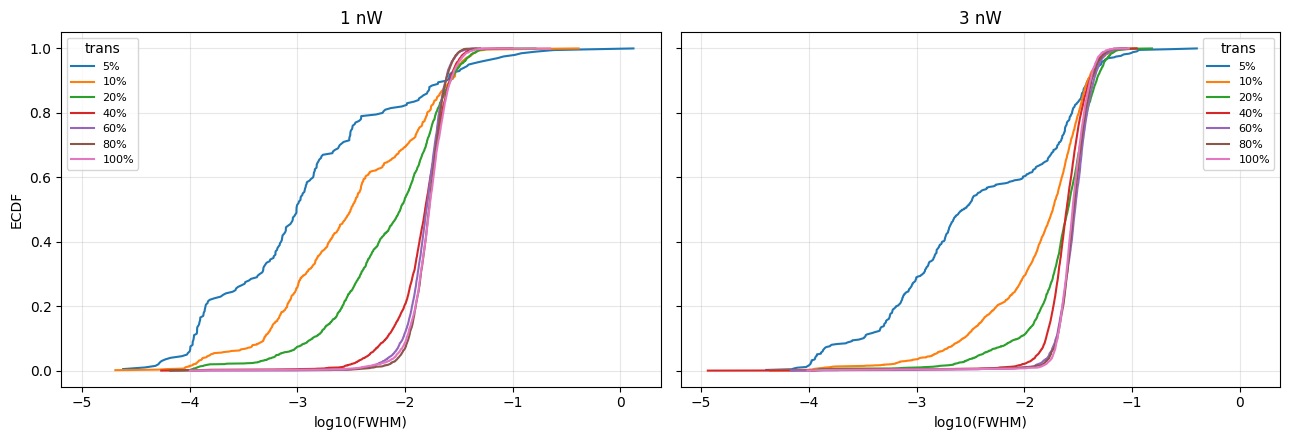

In [21]:
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys

fig, axes = plt.subplots(1, len(powers), figsize=(13, 4.5), sharex=True, sharey=True)
for ax, power in zip(np.atleast_1d(axes), powers):
    sub = valid[valid["power_nW"] == power]
    for t, g in sub.groupby("transmission"):
        xs, ys = ecdf(np.log10(g["fwhm"]))
        ax.plot(xs, ys, label=f"{t}%")
    ax.set(xlabel="log10(FWHM)", title=f"{power} nW")
    ax.legend(title="trans", fontsize=8)
np.atleast_1d(axes)[0].set_ylabel("ECDF")
plt.tight_layout()
plt.show()

### 8.4 Median FWHM heatmap (power × transmission)

A compact overview of the power-broadening trend across all 14 conditions.

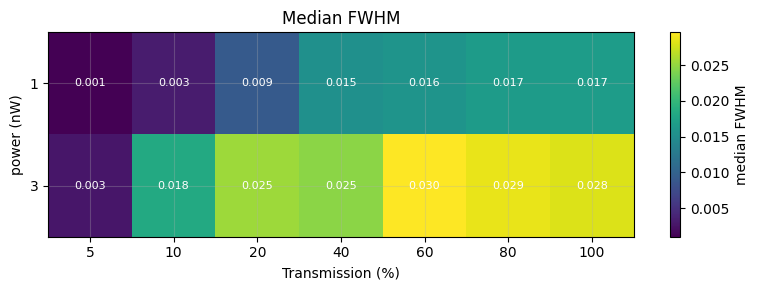

In [22]:
pivot = (valid.groupby(["power_nW", "transmission"])["fwhm"]
              .median()
              .unstack("transmission"))

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(pivot.shape[1]), pivot.columns)
ax.set_yticks(range(pivot.shape[0]), pivot.index)
ax.set(xlabel="Transmission (%)", ylabel="power (nW)",
       title="Median FWHM")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center",
                color="w", fontsize=8)
fig.colorbar(im, ax=ax, label="median FWHM")
plt.tight_layout()
plt.show()

### 8.5 Fit quality vs transmission

Median relative error `fit_error / fwhm` per condition — does higher transmission
also mean *better* (not just more) fits?

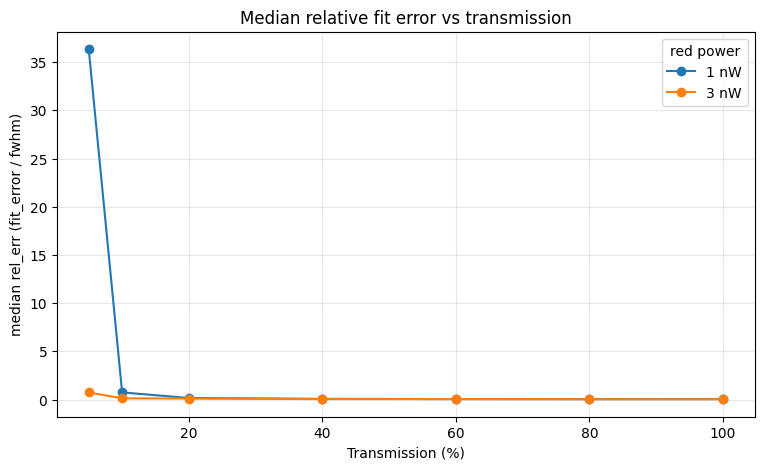

In [23]:
relq = (valid.assign(rel_err=valid["fit_error"] / valid["fwhm"])
             .groupby(["power_nW", "transmission"])["rel_err"]
             .median()
             .reset_index())

fig, ax = plt.subplots()
for power, g in relq.groupby("power_nW"):
    g = g.sort_values("transmission")
    ax.plot(g["transmission"], g["rel_err"], "o-", label=f"{power} nW")
ax.set(xlabel="Transmission (%)", ylabel="median rel_err (fit_error / fwhm)",
       title="Median relative fit error vs transmission")
ax.legend(title="red power")
plt.show()

## Step 9: Takeaways

*Fill in after running — bullet the observed trends here.*

- Failed-fit rate vs transmission: ...
- Power broadening (1 nW vs 3 nW): ...
- Relative-error distribution & a sensible quality threshold: ...
- Implication for the experimental FWHM distribution we match against: ...

**Open question (deferred):** absolute physical unit of the line width
(notebook MC currently works in MHz) — to confirm with Gregor.
